---
## 1. Setup <a id="sec-setup"></a>

The packages below cover every code cell in this notebook: `StructuralIdentifiability.jl` for the symbolic analysis itself, `Catalyst.jl`/`ModelingToolkit.jl` for the model-construction route of §4 (manuscript §3.4), `OrdinaryDiffEq.jl` for the numerical verification of non-identifiability by direct simulation (manuscript Figure 5), and `Plots.jl`/`StatsPlots.jl`/`LaTeXStrings.jl` for visualization.


> **Revision note (September 2026, v2).** This notebook accompanies the revised manuscript *A Tutorial on Symbolic Structural Identifiability Analysis of ODE Models in Julia* (BMAB-D-26-00484). It supersedes the notebook of the original submission. The case-study models, observation schemes, and expected verdicts follow the revised manuscript (Sections 5–6): the two-compartment model now observes the peripheral compartment (with the central-compartment variant as a remark), the viral-dynamics, SIWR, and SEIR-H results are stated as printed by `StructuralIdentifiability.jl`, and the chemical-reaction-network example of an intermediate draft is not included. The environment is pinned by the `Project.toml` and `Manifest.toml` shipped alongside this file (Julia 1.12, StructuralIdentifiability.jl 0.5.26). All outputs were cleared before archiving; run the notebook top to bottom (`Kernel → Restart & Run All`) in the pinned environment to regenerate them. Because the global algorithms are randomized, the printed form of generating sets can differ between runs, while verdicts do not.


In [1]:
# ==============================================================================
# REPRODUCIBILITY ENVIRONMENT
# ==============================================================================

using Pkg

# Activate the Julia environment shipped with this notebook.
# Project.toml and Manifest.toml must be in the same directory as the notebook.
Pkg.activate(@__DIR__)

# Install the exact dependency versions recorded in Manifest.toml.
# Do not use Pkg.add() or Pkg.update() here, as they may change the pinned versions.
Pkg.instantiate()

# Display the active environment and package versions.
println("\nActive Julia environment:")
println(Base.active_project())

println("\nJulia version:")
println(VERSION)

println("\nPackage status:")
Pkg.status()

  Activating project at `c:\Users\abdallah\Documents\Julia\Identifiability_tutorial_Revided_package`
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\abdallah\.julia\juliaup\julia-1.12.2+0.x64.w64.mingw32\share\julia\stdlib\v1.12\Pkg\src\API.jl:1255


Pkg.Types.PkgError: `Catalyst` is a direct dependency, but does not appear in the manifest. If you intend `Catalyst` to be a direct dependency, run `Pkg.resolve()` to populate the manifest. Otherwise, remove `Catalyst` with `Pkg.rm("Catalyst")`. Finally, run `Pkg.instantiate()` again.

In [2]:
using StructuralIdentifiability
using ModelingToolkit
using OrdinaryDiffEq
using Plots
gr()

using StatsPlots
using LinearAlgebra
using LaTeXStrings

println("Packages loaded successfully.")
println("Julia version: ", VERSION)
println("StructuralIdentifiability.jl version: ", pkgversion(StructuralIdentifiability))
println("ModelingToolkit.jl version:           ", pkgversion(ModelingToolkit))
println()
println("Core StructuralIdentifiability.jl functions used throughout this notebook:")
println("  assess_local_identifiability(model)   -> true / false per parameter and state   (Sedoglavic test, fast)")
println("  assess_identifiability(model)          -> :globally / :locally / :nonidentifiable  (differential elimination)")
println("  find_identifiable_functions(model)     -> generators of the identifiable field K_id")
println("  @ODEmodel(...)                         -> declare states, parameters, inputs, and outputs")

Packages loaded successfully.
Julia version: 1.12.2
StructuralIdentifiability.jl version: 0.5.26
ModelingToolkit.jl version:           11.38.1

Core StructuralIdentifiability.jl functions used throughout this notebook:
  assess_local_identifiability(model)   -> true / false per parameter and state   (Sedoglavic test, fast)
  assess_identifiability(model)          -> :globally / :locally / :nonidentifiable  (differential elimination)
  find_identifiable_functions(model)     -> generators of the identifiable field K_id
  @ODEmodel(...)                         -> declare states, parameters, inputs, and outputs


---
## 2. Mathematical Framework: The Parameter-to-Output Map <a id="sec-framework"></a>

*(This section condenses manuscript §2; see the manuscript for full derivations and references.)*

### The model class

$$\Sigma(\theta):\quad \dot{x}(t) = f\bigl(x(t), u(t); \theta\bigr), \qquad x(0) = x_0(\theta), \qquad y(t) = g\bigl(x(t), u(t); \theta\bigr)$$

with $x(t)\in\mathbb{R}^n$ the states, $u(t)\in\mathbb{R}^m$ a known input, $y(t)\in\mathbb{R}^q$ the measured output, and $\theta\in\Theta\subseteq\mathbb{R}^p$ the parameters. $f$ and $g$ are rational — this covers essentially every compartmental, mass-action, Michaelis–Menten, Hill-type (integer exponent), and viral-dynamics model used in practice.

### The parameter-to-output map

Unless initial conditions are declared known, we treat $(\theta, x_0)$ jointly as the unknown (the **augmented** formulation, manuscript §2.4), giving

$$\Phi:\Theta\times\mathbb{R}^n \longrightarrow \mathcal{Y}, \qquad (\theta, x_0)\mapsto y(\cdot;\theta,x_0).$$

Structural identifiability is a statement about the injectivity of $\Phi$ in $\theta$. The fibre $\Phi^{-1}(\Phi(\theta,x_0))$ is exactly the set of parameter values the data cannot distinguish.

### Classification (manuscript Eq. 2.3, holding for *almost every* $\theta\in\Theta$)

| Verdict | Definition | Fibre | Software symbol |
|---|---|---|---|
| **G** — globally identifiable | $\Phi(\theta)=\Phi(\tilde\theta) \Rightarrow \theta_i=\tilde\theta_i$ | single point | `:globally` |
| **L** — locally identifiable | the above holds only in a neighbourhood of $\theta$ | finite point set | `:locally` |
| **NI** — non-identifiable | every neighbourhood contains infinitely many consistent values | positive-dimensional variety | `:nonidentifiable` |

### Identifiable functions

Even when individual parameters are **NI**, some *functions* of the parameters may still be uniquely determined by the output. These form a subfield $\mathbb{K}_{\mathrm{id}}\subseteq\mathbb{Q}(\theta)$; `find_identifiable_functions` returns an explicit, finite generating set (Ovchinnikov, Pillay, Pogudin & Scanlon, 2022). Reparameterising the model in terms of these generators yields a model that is identifiable by construction (§12 below, manuscript §5).

### Algorithmic backbone

`StructuralIdentifiability.jl` combines two algorithms:
- **Local test** (Sedoglavic, 2002): a probabilistic, polynomial-time rank test on a sensitivity Jacobian — always run this first.
- **Global test** (Dong, Goodbrake, Harrington & Pogudin, 2023): differential elimination through projections, applied to the input–output equation obtained by eliminating unobserved states via repeated differentiation of the output equation.


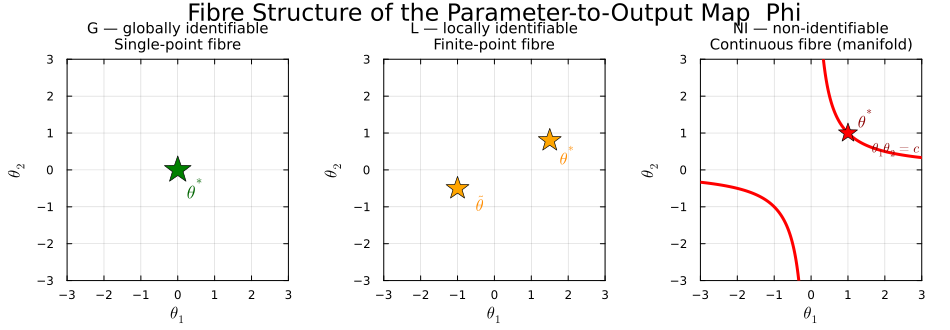

In [3]:
# ═══════════════════════════════════════════════════════════════
# Visualization: Three Types of Fibre Structure
# The fibre Phi^{-1}(Phi(theta)) determines the identifiability verdict.
# ═══════════════════════════════════════════════════════════════

p1 = plot(title="G — globally identifiable\nSingle-point fibre",
    xlabel=L"\theta_1", ylabel=L"\theta_2", legend=false,
    aspect_ratio=1, xlim=(-3,3), ylim=(-3,3),
    grid=true, framestyle=:box, titlefontsize=10)
scatter!(p1, [0.0], [0.0], markersize=14, color=:green, markershape=:star5)
annotate!(p1, 0.5, -0.5, text(L"\theta^*", 12, :darkgreen))

p2 = plot(title="L — locally identifiable\nFinite-point fibre",
    xlabel=L"\theta_1", ylabel=L"\theta_2", legend=false,
    aspect_ratio=1, xlim=(-3,3), ylim=(-3,3),
    grid=true, framestyle=:box, titlefontsize=10)
scatter!(p2, [1.5, -1.0], [0.8, -0.5], markersize=12, color=:orange, markershape=:star5)
annotate!(p2, 2.0, 0.4, text(L"\theta^*", 11, :darkorange))
annotate!(p2, -0.4, -0.9, text(L"\tilde{\theta}", 11, :darkorange))

p3 = plot(title="NI — non-identifiable\nContinuous fibre (manifold)",
    xlabel=L"\theta_1", ylabel=L"\theta_2", legend=false,
    aspect_ratio=1, xlim=(-3,3), ylim=(-3,3),
    grid=true, framestyle=:box, titlefontsize=10)
t_r = range(0.3, 3.0, length=200)
plot!(p3, t_r, 1.0 ./ t_r, linewidth=3, color=:red)
plot!(p3, -t_r, -1.0 ./ t_r, linewidth=3, color=:red)
scatter!(p3, [1.0], [1.0], markersize=10, color=:red, markershape=:star5)
annotate!(p3, 1.5, 1.4, text(L"\theta^*", 11, :darkred))
annotate!(p3, 2.3, 0.55, text(L"\theta_1 \theta_2 = c", 9, :darkred))

plot(p1, p2, p3, layout=(1,3), size=(950, 330),
    plot_title="Fibre Structure of the Parameter-to-Output Map  Phi",
    margin=5Plots.mm)

---
## 3. The Core API <a id="sec-api"></a>

*(Manuscript §3.3.)* Four constructs are used throughout every case study below.

### `@ODEmodel`

```julia
ode = @ODEmodel(
    x1'(t) = -k * x1(t),          # state equations (differentiated symbol = state)
    x2'(t) =  k * x1(t) - g * x2(t),
    y(t)   =  x2(t)                # observed output(s)
)
```
Every symbol on a differentiated left-hand side is a state; every other right-hand-side symbol is a parameter unless declared an input via `u(t)`; every symbol on the left of `y...(t) = ...` is an observed output. Multiple inputs and outputs are declared as additional equations.

### `assess_local_identifiability(ode; p = 0.99)`

Runs the Sedoglavic rank test. Returns `:locally` or `:nonidentifiable` for every parameter and initial condition. Typically completes in milliseconds; the correct first call in any analysis.

### `assess_identifiability(ode; funcs_to_check = [...])`

Runs the global differential-elimination test. Returns `:globally`, `:locally`, or `:nonidentifiable` for every parameter (and state, if `funcs_to_check` targets states). Passing specific rational combinations via `funcs_to_check` (e.g. `[a01 + a12, a01 * a12]`) tests whether *those* combinations — rather than the raw parameters — are identifiable.

### `find_identifiable_functions(ode; with_states = false)`

Returns a finite generating set of $\mathbb{K}_{\mathrm{id}}$: the rational functions of the parameters (and, with `with_states = true`, of the states) whose values are together determined by the output. This is the *constructive* counterpart to `assess_identifiability`: the latter labels parameters, the former tells the modeller what to estimate instead.


---
## 4. Building Models with `ModelingToolkit.jl` and `Catalyst.jl` <a id="sec-mtk"></a>

*(Manuscript §3.4.)* `@ODEmodel` is the most direct route to an identifiability problem, but many Julia users build models with `ModelingToolkit.jl` or, for reaction-network models, `Catalyst.jl`. Both interoperate with `StructuralIdentifiability.jl` through package extensions: a ModelingToolkit `System` is passed with the `measured_quantities` keyword, and a Catalyst `ReactionSystem` can be passed directly to `assess_identifiability`, `assess_local_identifiability`, and `find_identifiable_functions` (see the Catalyst documentation page *Structural identifiability analysis*). Note that the Catalyst extension eliminates conservation laws internally, so a conservation parameter appears in the output in place of one species; the parameter verdicts are unaffected.

A further benefit of this route is interoperability with standard exchange formats: `SBMLImporter.jl` imports SBML models as Catalyst `ReactionSystem` objects.


In [4]:
# ═══════════════════════════════════════════════════════════════
# Section 3.4 of the manuscript: two alternative model-construction routes.
# (a) ModelingToolkit System  -> assess_identifiability(sys; measured_quantities = ...)
# (b) Catalyst ReactionSystem -> assess_identifiability(rn;  measured_quantities = ...)
#     (Catalyst's StructuralIdentifiability extension; conservation laws are eliminated
#      internally, so the printed set of quantities may differ from the @ODEmodel version;
#      the parameter verdicts must agree because the parameter-to-output map is the same.)
# Compare with Case Study 2 below: beta and gamma are globally identifiable.
# ═══════════════════════════════════════════════════════════════
using Logging

# (a) ModelingToolkit route
@independent_variables t
D = Differential(t)
@parameters beta gamma
@variables S(t) I(t) R(t) y(t)
eqs = [D(S) ~ -beta*S*I,
       D(I) ~  beta*S*I - gamma*I,
       D(R) ~  gamma*I]
@named sir_mtk = System(eqs, t)
res_mtk = assess_identifiability(sir_mtk; measured_quantities = [y ~ beta*S*I], loglevel = Logging.Error)
println("-- ModelingToolkit System, y = beta*S*I --")
for (k, v) in res_mtk
    println("  ", k, " => ", v)
end

# (b) Catalyst route (requires Catalyst in the environment; see README)
try
    @eval using Catalyst
    sir_rn = @reaction_network begin
        beta,  S + I --> 2I
        gamma, I --> R
    end
    @unpack S, I, beta = sir_rn
    res_catalyst = assess_identifiability(sir_rn; measured_quantities = [beta * S * I], loglevel = Logging.Error)
    println("\n-- Catalyst ReactionSystem, y = beta*S*I --")
    for (k, v) in res_catalyst
        println("  ", k, " => ", v)
    end
catch err
    println("\nCatalyst route skipped: ", sprint(showerror, err))
    println("Add Catalyst to the environment (see README: `Pkg.add(\"Catalyst\")` followed by re-instantiation) and re-run.")
end
println("\n=> Expected: beta and gamma globally identifiable on both routes, as in Case Study 2.")


-- ModelingToolkit System, y = beta*S*I --
  S(t) => globally
  I(t) => globally
  R(t) => nonidentifiable
  beta => globally
  gamma => globally


LoadError: LoadError: UndefVarError: `@reaction_network` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at c:\Users\abdallah\Documents\Julia\Identifiability_tutorial_Revided_package\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X11sZmlsZQ==.jl:30

---
## 5. Case Study 1: Exponential Decay <a id="sec-ex1"></a>

*(Manuscript §5.1.)* The simplest non-trivial ODE in pharmacokinetics (single-compartment elimination), radioactive decay, and first-order chemical kinetics. It is the calibration example: a model that is globally identifiable for the most evident reason possible.

### Model

$$\dot{x}(t) = -k\,x(t), \qquad x(0) = x_0, \qquad y(t) = x(t)$$

The closed-form solution $x(t) = x_0 e^{-kt}$ makes it transparent: a single noiseless observation at any positive time, together with $x(0)$, uniquely determines $k$.


In [5]:
# ═══════════════════════════════════════════════════════════════
# Case Study 1 — Exponential decay
# ═══════════════════════════════════════════════════════════════

decay = @ODEmodel(
    x'(t) = -k * x(t),
    y(t)  =  x(t)
)

println("-- Local identifiability --")
for (p, s) in assess_local_identifiability(decay)
    println("  ", p, " => ", s)
end

println("\n-- Global identifiability --")
for (p, s) in assess_identifiability(decay)
    println("  ", p, " => ", s)
end

println("\n=> Expected (manuscript Section 5.1): k and x(0) are both globally identifiable (G).")

-- Local identifiability --
  x(t) => true
  k => true

-- Global identifiability --


[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.000555 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0003836 seconds
[ Info: Dimensions of the Wronskians [2]
[ Info: Ranks of the Wronskians computed in 1.13e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard


  x(t) => globally
  k => globally

=> Expected (manuscript Section 5.1): k and x(0) are both globally identifiable (G).


[ Info: Search for polynomial generators concluded in 0.036463
[ Info: Selecting generators in 0.0001233
[ Info: Inclusion checked with probability 0.9955 in 0.0012998 seconds
[ Info: Global identifiability assessed in 0.1907663 seconds


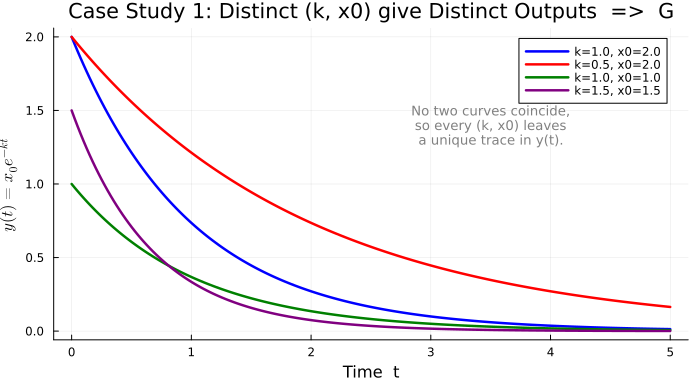

In [6]:
# ═══════════════════════════════════════════════════════════════
# Visualization: distinct (k, x0) pairs give distinct output curves
# — the geometric meaning of "globally identifiable."
# ═══════════════════════════════════════════════════════════════

t = range(0, 5, length=200)

p = plot(xlabel="Time  t", ylabel=L"y(t) = x_0 e^{-kt}",
    title="Case Study 1: Distinct (k, x0) give Distinct Outputs  =>  G",
    legend=:topright, size=(700, 380))

configs = [(1.0, 2.0, "k=1.0, x0=2.0"), (0.5, 2.0, "k=0.5, x0=2.0"),
           (1.0, 1.0, "k=1.0, x0=1.0"), (1.5, 1.5, "k=1.5, x0=1.5")]
cols = [:blue, :red, :green, :purple]

for (i, (k, x0, lbl)) in enumerate(configs)
    plot!(p, t, x0 .* exp.(-k .* t), linewidth=2.5, label=lbl, color=cols[i])
end

annotate!(p, 3.5, 1.4, text("No two curves coincide,\nso every (k, x0) leaves\na unique trace in y(t).", 9, :gray))
p

### Bonus exploration: a scaled observation breaks global identifiability

A closely related model — common in pharmacokinetics, where the observation channel (assay, detector) carries its own unknown scaling — is $\dot x = -kx$, $y = a\,x$, with $a$ an unknown scale factor. This is **not** one of the manuscript's seven case studies, but it is instructive because it isolates exactly the kind of confounding later seen in the viral-dynamics model (Case Study 4): a parameter multiplying the *initial condition* rather than the dynamics.


In [7]:
# ═══════════════════════════════════════════════════════════════
# Bonus: dx/dt = -kx,  y = a*x   (scaled observation)
# ═══════════════════════════════════════════════════════════════

decay_scaled = @ODEmodel(
    x'(t) = -k * x(t),
    y(t) = a * x(t)
)

println("-- Global identifiability --")
for (p, s) in assess_identifiability(decay_scaled)
    println("  ", p, " => ", s)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(decay_scaled))

println("\n=> k is G; a and x(0) are individually NI; the identifiable")
println("   combination is the product a*x(0). The fibre is the")
println("   hyperbola {a*x0 = const} in the (a, x0) plane.")

-- Global identifiability --


[ Info: Summary of the model:
[ Info: State variables: x
[ Info: Parameters: a, k
[ Info: Inputs: 
[ Info: Outputs: y


  x(t) => nonidentifiable
  a => nonidentifiable
  k => globally

-- Identifiable functions --


[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0005591 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0003874 seconds
[ Info: Dimensions of the Wronskians [2]
[ Info: Ranks of the Wronskians computed in 8.6e-6 seconds
[ Info: Global identifiability assessed in 0.0024504 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.000622 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0003981 seconds
[ Info: Dimensions of the Wronskians [2]
[ Info: Ranks of the Wronskians computed in 9.8e-6 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.090892
[ Info: Selecting generators in 0.2035478
[ Info: Inclusion checked with probability 0.995 in 0.0015703 seconds
[ Info: The search for identifiable functions concluded in 0.5463113 seconds


  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[k]

=> k is G; a and x(0) are individually NI; the identifiable
   combination is the product a*x(0). The fibre is the
   hyperbola {a*x0 = const} in the (a, x0) plane.


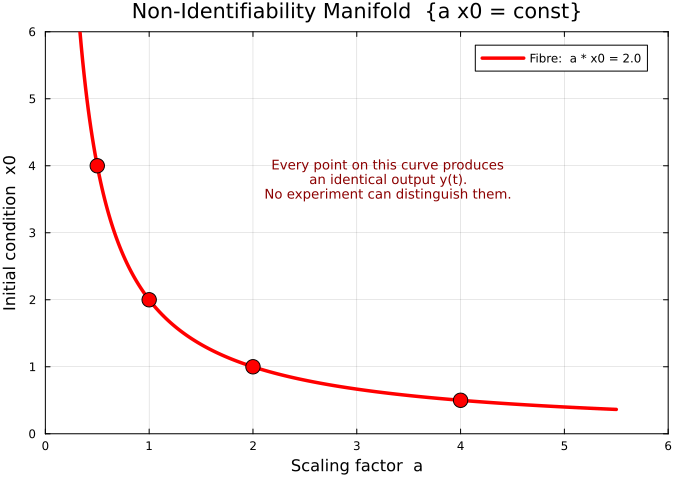

In [8]:
# ═══════════════════════════════════════════════════════════════
# Visualization: the non-identifiability manifold {a*x0 = const}
# and the fact that every point on it gives an IDENTICAL output.
# ═══════════════════════════════════════════════════════════════

c_true = 2.0  # the identifiable product a*x0

a_vals  = range(0.2, 5.5, length=400)
x0_vals = c_true ./ a_vals

p1 = plot(a_vals, x0_vals, linewidth=3.5, color=:red,
    label="Fibre:  a * x0 = $(c_true)",
    xlabel="Scaling factor  a", ylabel="Initial condition  x0",
    title="Non-Identifiability Manifold  {a x0 = const}",
    xlim=(0, 6), ylim=(0, 6), size=(680, 480), framestyle=:box,
    legend=:topright)

for (a, x0) in [(0.5, 4.0), (1.0, 2.0), (2.0, 1.0), (4.0, 0.5)]
    scatter!(p1, [a], [x0], markersize=8, color=:red, label=nothing)
end
annotate!(p1, 3.3, 3.8, text("Every point on this curve produces\nan identical output y(t).\nNo experiment can distinguish them.", 9, :darkred))
p1

---
## 6. Case Study 2: SIR Epidemic Model <a id="sec-ex2"></a>

*(Manuscript §5.2.)* The founding compartmental model of mathematical epidemiology (Kermack & McKendrick, 1927).

### Model

$$\dot S = -\beta\,SI, \qquad \dot I = \beta\,SI - \gamma\,I, \qquad \dot R = \gamma\,I$$

with $\theta=(\beta,\gamma)$. Surveillance practice reports **incidence** — the rate of new infections — corresponding to the output

$$y(t) = \beta\,S(t)\,I(t).$$

This is a useful counterexample to a common misconception: incidence alone identifies *both* rate parameters, despite the cumulative compartment $R$ never being observed.


In [9]:
# ═══════════════════════════════════════════════════════════════
# Case Study 2 — SIR model, incidence observed
# ═══════════════════════════════════════════════════════════════

sir = @ODEmodel(
    S'(t) = -beta * S(t) * I(t),
    I'(t) =  beta * S(t) * I(t) - gamma * I(t),
    R'(t) =  gamma * I(t),
    y(t)  =  beta * S(t) * I(t)
)

println("-- Global identifiability --")
for (p, s) in assess_identifiability(sir)
    println("  ", p, " => ", s)
end

println("\n=> Expected (manuscript Section 5.2): beta and gamma both G;")
println("   R is correctly reported as unobservable (does not enter the")
println("   input-output relation derived from y). R0 = beta*S(0)/gamma")
println("   is therefore identifiable whenever S(0) is known.")

-- Global identifiability --
  S(t) => globally
  I(t) => globally
  R(t) => nonidentifiable
  beta => globally
  gamma => globally

=> Expected (manuscript Section 5.2): beta and gamma both G;
   R is correctly reported as unobservable (does not enter the
   input-output relation derived from y). R0 = beta*S(0)/gamma
   is therefore identifiable whenever S(0) is known.


[ Info: Summary of the model:
[ Info: State variables: S, I, R
[ Info: Parameters: beta, gamma
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0307034 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0013082 seconds
[ Info: Dimensions of the Wronskians [7]
[ Info: Ranks of the Wronskians computed in 1.13e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0002715
[ Info: Selecting generators in 0.000809
[ Info: Inclusion checked with probability 0.9955 in 0.0015975 seconds
[ Info: Global id

### Bonus exploration: alternative observation schemes

What happens if the surveillance system reports **prevalence** $y=I(t)$ instead of incidence, or **both** $I(t)$ and $R(t)$? These variants are not analysed in the manuscript, but they are worth running because the SIR model's *nonlinear* coupling makes the answer less obvious than the linear examples above: unlike the pure-scaling confounding of Case Study 1, the quadratic term $\beta SI$ can break a naive scaling symmetry between $\beta$ and $S(0)$.


In [10]:
# ═══════════════════════════════════════════════════════════════
# Bonus: SIR with prevalence y = I(t), and with (I, R) jointly observed
# ═══════════════════════════════════════════════════════════════

println("="^60); println("  SIR, y = I(t) only (prevalence)"); println("="^60)
sir_I = @ODEmodel(
    S'(t) = -beta * S(t) * I(t),
    I'(t) =  beta * S(t) * I(t) - gamma * I(t),
    R'(t) =  gamma * I(t),
    y(t)  =  I(t)
)
for (p, s) in assess_identifiability(sir_I); println("  ", p, " => ", s); end

println("\n", "="^60); println("  SIR, y1 = I(t), y2 = R(t)"); println("="^60)
sir_IR = @ODEmodel(
    S'(t) = -beta * S(t) * I(t),
    I'(t) =  beta * S(t) * I(t) - gamma * I(t),
    R'(t) =  gamma * I(t),
    y1(t) =  I(t),
    y2(t) =  R(t)
)
for (p, s) in assess_identifiability(sir_IR); println("  ", p, " => ", s); end

println("\n=> Run this cell yourself and record the verdicts. In our runs,")
println("   both variants also render beta and gamma globally identifiable")
println("   (only R itself, or nothing, remains unobservable) — a reminder")
println("   that nonlinear coupling can defeat confounding that would be")
println("   fatal in a linear model. Always verify computationally rather")
println("   than assuming a linear-model intuition transfers.")

  SIR, y = I(t) only (prevalence)
  S(t) => globally
  I(t) => globally
  R(t) => nonidentifiable
  beta => globally
  gamma => globally

  SIR, y1 = I(t), y2 = R(t)


[ Info: Summary of the model:
[ Info: State variables: S, I, R
[ Info: Parameters: beta, gamma
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0012308 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0010555 seconds
[ Info: Dimensions of the Wronskians [3]
[ Info: Ranks of the Wronskians computed in 1.08e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0003524
[ Info: Selecting generators in 0.0005465
[ Info: Inclusion checked with probability 0.9955 in 0.0012634 seconds
[ Info: Global i

  S(t) => globally
  I(t) => globally
  R(t) => globally
  beta => globally
  gamma => globally

=> Run this cell yourself and record the verdicts. In our runs,
   both variants also render beta and gamma globally identifiable
   (only R itself, or nothing, remains unobservable) — a reminder
   that nonlinear coupling can defeat confounding that would be
   fatal in a linear model. Always verify computationally rather
   than assuming a linear-model intuition transfers.


[ Info: Search for polynomial generators concluded in 0.0002768
[ Info: Selecting generators in 0.0006714
[ Info: Inclusion checked with probability 0.9955 in 0.0015819 seconds
[ Info: Global identifiability assessed in 2.6204671 seconds


---
## 7. Case Study 3: Two-Compartment Pharmacokinetic Model <a id="sec-ex3"></a>

*(Manuscript §5.3.)* The textbook example of a model with an exchange symmetry, dating to Bellman & Åström (1970); this is also the introductory example of the `StructuralIdentifiability.jl` documentation.

### Model

$$\dot x_1 = -(a_{01}+a_{21})\,x_1 + a_{12}\,x_2 + u, \qquad \dot x_2 = a_{21}\,x_1 - a_{12}\,x_2, \qquad y = x_2$$

with $\theta=(a_{01},a_{12},a_{21})$: a known input $u(t)$ enters the central compartment $x_1$ and the **peripheral** compartment $x_2$ is measured. The input–output equation is $\ddot y+(a_{01}+a_{12}+a_{21})\dot y+a_{01}a_{12}y=a_{21}u$, so $a_{21}$, $a_{01}+a_{12}$, $a_{01}a_{12}$ are globally identifiable and $a_{01},a_{12}$ only up to exchange.

**Measurement scheme matters.** If instead the central compartment is observed ($y=x_1$, input gain $b$), the input–output equation is $\ddot y+(a_{01}+a_{12}+a_{21})\dot y+a_{01}a_{12}y=b\dot u+ba_{12}u$ and *all* parameters are globally identifiable. Both variants are run below.


In [11]:
# ═══════════════════════════════════════════════════════════════
# Case Study 3 — Two-compartment PK, peripheral compartment observed
# ═══════════════════════════════════════════════════════════════

pk = @ODEmodel(
    x1'(t) = -(a01 + a21) * x1(t) + a12 * x2(t) + u(t),
    x2'(t) =   a21 * x1(t) - a12 * x2(t),
    y(t)   =   x2(t)
)

println("-- Global identifiability, y = x2 --")
for (p, s) in assess_identifiability(pk)
    println("  ", p, " => ", s)
end

println("\n-- Checking the symmetric combinations a01+a12 and a01*a12 --")
for (f, s) in assess_identifiability(pk, funcs_to_check = [a01 + a12, a01 * a12])
    println("  ", f, " => ", s)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(pk))

println("\n=> Expected (manuscript Section 5.3): x2 => G, x1 => L, a01 => L, a12 => L, a21 => G;")
println("   generators {a21, a01 + a12, a01*a12}.")

# ---- Variant: central compartment observed, unknown input gain b -------------
pk_central = @ODEmodel(
    x1'(t) = -(a01 + a21) * x1(t) + a12 * x2(t) + b * u(t),
    x2'(t) =   a21 * x1(t) - a12 * x2(t),
    y(t)   =   x1(t)
)
println("\n-- Global identifiability, y = x1 (central compartment, gain b) --")
for (p, s) in assess_identifiability(pk_central)
    println("  ", p, " => ", s)
end
println("  identifiable functions: ", find_identifiable_functions(pk_central))
println("\n=> Expected: every parameter and both states globally identifiable.")


-- Global identifiability, y = x2 --


[ Info: Summary of the model:
[ Info: State variables: x1, x2
[ Info: Parameters: a01, a12, a21
[ Info: Inputs: u
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0010839 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0007371 seconds
[ Info: Dimensions of the Wronskians [4]
[ Info: Ranks of the Wronskians computed in 8.1e-6 seconds
[ Info: Simplifying generating set. Simplification level: standard


  x1(t) => locally
  x2(t) => globally
  a01 => locally
  a12 => locally
  a21 => globally

-- Checking the symmetric combinations a01+a12 and a01*a12 --


[ Info: Search for polynomial generators concluded in 0.0388544
[ Info: Selecting generators in 0.0009887
[ Info: Inclusion checked with probability 0.9955 in 0.0020293 seconds
[ Info: Global identifiability assessed in 0.0625023 seconds


[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0010033 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0006675 seconds
[ Info: Dimensions of the Wronskians [4]
[ Info: Ranks of the Wronskians computed in 1.63e-5 seconds
[ Info: Global identifiability assessed in 0.0036913 seconds


...

[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0010129 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0006996 seconds
[ Info: Dimensions of the Wronskians [4]
[ Info: Ranks of the Wronskians computed in 8.5e-6 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0015216
[ Info: Selecting generators in 0.0009898
[ Info: Inclusion checked with probability 0.995 in 0.0019911 seconds
[ Info: The search for identifiable functions concluded in 0.0098465 seconds


a01 + a12, a01*a12]

=> Expected (manuscript Section 5.3): x2 => G, x1 => L, a01 => L, a12 => L, a21 => G;
   generators {a21, a01 + a12, a01*a12}.

-- Global identifiability, y = x1 (central compartment, gain b) --


[ Info: Summary of the model:
[ Info: State variables: x1, x2
[ Info: Parameters: a01, a12, a21, b
[ Info: Inputs: u
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.001039 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0007121 seconds
[ Info: Dimensions of the Wronskians [5]
[ Info: Ranks of the Wronskians computed in 1.75e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard


  x1(t) => globally
  x2(t) => globally
  a01 => globally
  a12 => globally
  a21 => globally
  b => globally
  identifiable functions: AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[b, a21, a12, a01]

=> Expected: every parameter and both states globally identifiable.


[ Info: Search for polynomial generators concluded in 0.0386718
[ Info: Selecting generators in 0.0010319
[ Info: Inclusion checked with probability 0.9955 in 0.0020096 seconds
[ Info: Global identifiability assessed in 0.2330006 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0010946 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0007574 seconds
[ Info: Dimensions of the Wronskians [5]
[ Info: Ranks of the Wronskians computed in 8.5e-6 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0004572
[ Info: Selecting generators in 0.0009717
[ Info: Inclusion checked with probability 0.995 in 0.0019508 seconds
[ Info: The search for identifiable functions concluded in 0.009149 seconds


### Numerical verification of the exchange symmetry (reproduces manuscript Figure 5B)

Structural identifiability results are algebraic claims; they can — and should — be checked by direct simulation. The cell below integrates the model for the two parameter sets related by the $a_{01}\leftrightarrow a_{12}$ exchange, from the *same* bolus initial condition $x_1(0)=10$, $x_2(0)=0$, and confirms that the two trajectories of the observed peripheral compartment $x_2(t)$ are numerically indistinguishable.


Maximum |x2_A(t) - x2_B(t)| over t in [0,10]: 1.0724754417879012e-13


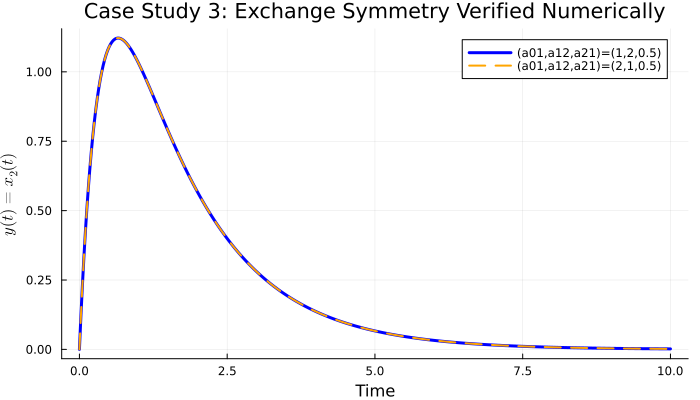

In [12]:
# ═══════════════════════════════════════════════════════════════
# Numerical verification: (a01, a12) exchange symmetry, y = x2
# Reproduces manuscript Figure 5(B).
# ═══════════════════════════════════════════════════════════════

function pk_rhs!(du, u, p, t)
    x1, x2 = u
    a01, a12, a21 = p
    du[1] = -(a01 + a21) * x1 + a12 * x2      # bolus dose modelled as x1(0); u(t) = 0 afterwards
    du[2] =  a21 * x1 - a12 * x2
end

tspan = (0.0, 10.0)
u0 = [10.0, 0.0]                              # same initial condition for both parameter sets
solA = solve(ODEProblem(pk_rhs!, u0, tspan, (1.0, 2.0, 0.5)), Tsit5(), reltol=1e-12, abstol=1e-12)
solB = solve(ODEProblem(pk_rhs!, u0, tspan, (2.0, 1.0, 0.5)), Tsit5(), reltol=1e-12, abstol=1e-12)

t_check = range(0, 10, length=400)
yA = [solA(ti)[2] for ti in t_check]
yB = [solB(ti)[2] for ti in t_check]
println("Maximum |x2_A(t) - x2_B(t)| over t in [0,10]: ", maximum(abs.(yA .- yB)))

plot(t_check, yA, linewidth=3, color=:blue, label="(a01,a12,a21)=(1,2,0.5)",
    xlabel="Time", ylabel=L"y(t)=x_2(t)", title="Case Study 3: Exchange Symmetry Verified Numerically", size=(700, 400))
plot!(t_check, yB, linewidth=2, linestyle=:dash, color=:orange, label="(a01,a12,a21)=(2,1,0.5)")


In [13]:
# ═══════════════════════════════════════════════════════════════
# Case Study 3, variant: central compartment observed with an input of unknown gain b
# (the model of the original submission).  Manuscript Section 5.3, remark; Table 3 row "PK (central)".
# ═══════════════════════════════════════════════════════════════
pk_x1 = @ODEmodel(
    x1'(t) = -(a01 + a21) * x1(t) + a12 * x2(t) + b * u(t),
    x2'(t) =   a21 * x1(t) - a12 * x2(t),
    y(t)   =   x1(t)
)
println("-- Global identifiability, y = x1, input b*u --")
for (p, s) in assess_identifiability(pk_x1)
    println("  ", p, " => ", s)
end
println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(pk_x1))
println("\n=> Expected: all of a01, a12, a21, b globally identifiable; x1, x2 observable")
println("   (input-output equation y'' + (a01+a12+a21) y' + a01*a12 y = b u' + b*a12 u).")


-- Global identifiability, y = x1, input b*u --
  x1(t) => globally
  x2(t) => globally
  a01 => globally
  a12 => globally
  a21 => globally
  b => globally

-- Identifiable functions --
  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[b, a21, a12, a01]

=> Expected: all of a01, a12, a21, b globally identifiable; x1, x2 observable
   (input-output equation y'' + (a01+a12+a21) y' + a01*a12 y = b u' + b*a12 u).


[ Info: Summary of the model:
[ Info: State variables: x1, x2
[ Info: Parameters: a01, a12, a21, b
[ Info: Inputs: u
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0010181 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0006931 seconds
[ Info: Dimensions of the Wronskians [5]
[ Info: Ranks of the Wronskians computed in 1.93e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0004307
[ Info: Selecting generators in 0.0009063
[ Info: Inclusion checked with probability 0.9955 in 0.0017616 seconds
[ Info: Global identifiability assessed in 0.0108815 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0009925 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0007005 seconds
[ Info: Dimensi

---
## 8. Case Study 4: Within-Host Viral Dynamics <a id="sec-ex4"></a>

*(Manuscript §5.4.)* The Perelson et al. (1996) model that revolutionised HIV modelling, reducing immune dynamics to three coupled compartments.

### Model

$$\dot T = s - d_T\,T - \beta\,TV, \qquad \dot I = \beta\,TV - \delta\,I, \qquad \dot V = p\,I - c\,V$$

with $\theta=(s, d_T, \beta, \delta, p, c)$. Free virus $V$ is the only quantity directly measurable in most clinical studies: $y(t)=V(t)$.


In [14]:
# ═══════════════════════════════════════════════════════════════
# Case Study 4 — Within-host viral dynamics, y = V(t) only
# ═══════════════════════════════════════════════════════════════

viral = @ODEmodel(
    T'(t) = s - dT * T(t) - beta * T(t) * V(t),
    I'(t) = beta * T(t) * V(t) - delta * I(t),
    V'(t) = p * I(t) - c * V(t),
    y(t)  = V(t)
)

println("-- Global identifiability --")
for (p, st) in assess_identifiability(viral)
    println("  ", p, " => ", st)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(viral))

println("\n=> Expected (manuscript Section 5.4): beta and dT globally identifiable;")
println("   c and delta locally (exchange c <-> delta: only c+delta and c*delta determined);")
println("   p and s non-identifiable, entering only through the product p*s, because")
println("   (T, I, s, p) -> (λT, λI, λs, p/λ) leaves V(t) unchanged. T and I unobservable.")


-- Global identifiability --


[ Info: Summary of the model:
[ Info: State variables: T, I, V
[ Info: Parameters: beta, c, dT, delta, p, s
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0016276 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0012994 seconds
[ Info: Dimensions of the Wronskians [8]
[ Info: Ranks of the Wronskians computed in 2.13e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0489116
[ Info: Selecting generators in 0.0024134
[ Info: Inclusion checked with probability 0.9955 in 0.0028793 seconds
[ Info: Global identifiability assessed in 4.4425341 seconds


  T(t) => nonidentifiable
  I(t) => nonidentifiable
  V(t) => globally
  beta => globally
  c => locally
  dT => globally
  delta => locally
  p => nonidentifiable
  s => nonidentifiable

-- Identifiable functions --
  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[dT, beta, c + delta, p*s, c*delta]

=> Expected (manuscript Section 5.4): beta and dT globally identifiable;
   c and delta locally (exchange c <-> delta: only c+delta and c*delta determined);
   p and s non-identifiable, entering only through the product p*s, because
   (T, I, s, p) -> (λT, λI, λs, p/λ) leaves V(t) unchanged. T and I unobservable.


[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0018297 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0012919 seconds
[ Info: Dimensions of the Wronskians [8]
[ Info: Ranks of the Wronskians computed in 1.11e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0108308
[ Info: Selecting generators in 0.0023465
[ Info: Inclusion checked with probability 0.995 in 0.0024228 seconds
[ Info: The search for identifiable functions concluded in 0.0257109 seconds


### Restoring identifiability with a second observable

Measuring the uninfected target-cell count $T(t)$ (e.g. via flow cytometry) resolves the $\beta$–$p$ confounding, since $\dot T = s - d_T T - \beta TV$ becomes directly observable.


In [15]:
# ═══════════════════════════════════════════════════════════════
# Restoring identifiability: y1 = V(t), y2 = T(t)
# ═══════════════════════════════════════════════════════════════

viral_augmented = @ODEmodel(
    T'(t) = s - dT * T(t) - beta * T(t) * V(t),
    I'(t) = beta * T(t) * V(t) - delta * I(t),
    V'(t) = p * I(t) - c * V(t),
    y1(t) = V(t),
    y2(t) = T(t)
)

println("-- Global identifiability, y1=V, y2=T --")
for (p, s) in assess_identifiability(viral_augmented)
    println("  ", p, " => ", s)
end

println("\n=> Expected: s, dT, beta, p become globally identifiable and T, V observable;")
println("   c and delta remain locally identifiable (the c <-> delta exchange survives).")


-- Global identifiability, y1=V, y2=T --


[ Info: Summary of the model:
[ Info: State variables: T, I, V
[ Info: Parameters: beta, c, dT, delta, p, s
[ Info: Inputs: 
[ Info: Outputs: y1, y2
[ Info: Assessing local identifiability


  T(t) => globally
  I(t) => locally
  V(t) => globally
  beta => globally
  c => locally
  dT => globally
  delta => locally
  p => globally
  s => globally

=> Expected: s, dT, beta, p become globally identifiable and T, V observable;
   c and delta remain locally identifiable (the c <-> delta exchange survives).


[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0036285 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0011977 seconds
[ Info: Dimensions of the Wronskians [4, 4]
[ Info: Ranks of the Wronskians computed in 1.1e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.008974
[ Info: Selecting generators in 0.0019597
[ Info: Inclusion checked with probability 0.9955 in 0.0025592 seconds
[ Info: Global identifiability assessed in 0.0283454 seconds


In [16]:
# ═══════════════════════════════════════════════════════════════
# Case Study 4, remark: a known initial condition T(0) removes the continuous (scaling) ambiguity.
# Uses the experimental `known_ic` keyword of StructuralIdentifiability.jl; wrapped in try/catch
# because the interface of experimental features may change between releases.
# ═══════════════════════════════════════════════════════════════
try
    res_known = assess_identifiability(viral; known_ic = [T])
    println("-- Global identifiability, y = V, T(0) known --")
    for (p, s) in res_known
        println("  ", p, " => ", s)
    end
    println("\n=> Expected: p and s no longer lie on a continuous fibre (the scaling symmetry is broken by")
    println("   the known T(0)); c and delta remain locally identifiable.")
catch err
    println("known_ic call skipped in this release: ", sprint(showerror, err))
end


known_ic call skipped in this release: parents do not match


[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0019449 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.001293 seconds
[ Info: Dimensions of the Wronskians [8]
[ Info: Ranks of the Wronskians computed in 1.98e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0109884
[ Info: Selecting generators in 0.002427
[ Info: Inclusion checked with probability 0.99875 in 0.002437 seconds
[ Info: The search for identifiable functions concluded in 0.0267542 seconds


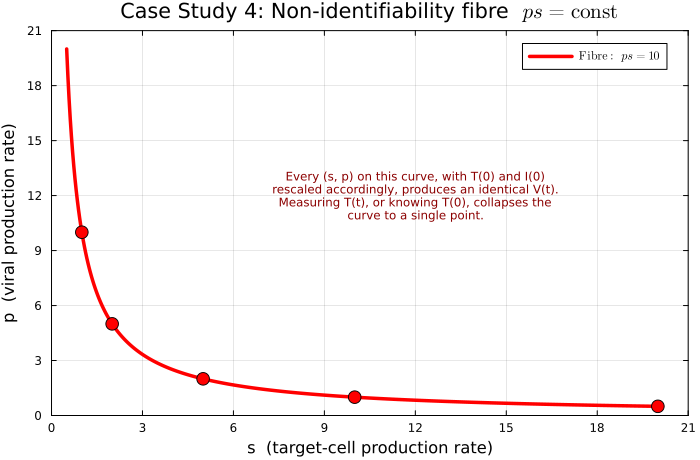

In [17]:
# ═══════════════════════════════════════════════════════════════
# Visualization: the p*s non-identifiability fibre (Case Study 4, y = V only)
# The continuous symmetry (T, I, s, p) -> (lambda*T, lambda*I, lambda*s, p/lambda)
# leaves V(t) unchanged, so only the product p*s is identifiable.
# ═══════════════════════════════════════════════════════════════
c_true = 10.0        # representative value of the identifiable product p*s

s_r = range(0.5, 20.0, length=500)
p_r = c_true ./ s_r

pv = plot(s_r, p_r, linewidth=3.5, color=:red,
    xlabel="s  (target-cell production rate)", ylabel="p  (viral production rate)",
    title="Case Study 4: Non-identifiability fibre  " * L"ps = \mathrm{const}",
    legend=:topright, size=(700, 460),
    label=L"\mathrm{Fibre:}\ ps = 10",
    framestyle=:box, xlim=(0, 21), ylim=(0, 21))

for s_val in [1.0, 2.0, 5.0, 10.0, 20.0]
    scatter!(pv, [s_val], [c_true / s_val], markersize=7, color=:red, label=nothing)
end

annotate!(pv, 12.0, 12.0,
    text("Every (s, p) on this curve, with T(0) and I(0)\nrescaled accordingly, produces an identical V(t).\nMeasuring T(t), or knowing T(0), collapses the\ncurve to a single point.", 8, :darkred))
pv


In [18]:
# ═══════════════════════════════════════════════════════════════
# Numerical verification of the scaling symmetry of Case Study 4:
# (T, I, s, p) -> (lambda*T, lambda*I, lambda*s, p/lambda) leaves V(t) unchanged.
# ═══════════════════════════════════════════════════════════════
function viral_rhs!(du, u, par, t)
    T, I, V = u
    s, dT, beta, delta, p, c = par
    du[1] = s - dT*T - beta*T*V
    du[2] = beta*T*V - delta*I
    du[3] = p*I - c*V
end
lam = 3.0
parA = (10.0, 0.1, 2e-3, 0.5, 5.0, 3.0);      u0A = [1000.0, 10.0, 1.0]
parB = (lam*10.0, 0.1, 2e-3, 0.5, 5.0/lam, 3.0); u0B = [lam*1000.0, lam*10.0, 1.0]
solA = solve(ODEProblem(viral_rhs!, u0A, (0.0, 30.0), parA), Tsit5(), reltol=1e-12, abstol=1e-12)
solB = solve(ODEProblem(viral_rhs!, u0B, (0.0, 30.0), parB), Tsit5(), reltol=1e-12, abstol=1e-12)
tt = range(0, 30, length=300)
println("max |V_A(t) - V_B(t)| = ", maximum(abs.([solA(ti)[3] - solB(ti)[3] for ti in tt])))
println("=> identical viral-load curves for two parameter sets with the same p*s (and same beta, dT, c, delta).")


max |V_A(t) - V_B(t)| = 4.058620106661692e-11
=> identical viral-load curves for two parameter sets with the same p*s (and same beta, dT, c, delta).


---
## 9. Case Study 5: SIWR Environmental Transmission Model <a id="sec-ex5"></a>

*(Manuscript §5.5.)* For pathogens with substantial environmental transmission (e.g. *Vibrio cholerae*, rotavirus), the SIR framework is augmented with a pathogen reservoir $W$.

### Model

$$\dot S = -\beta_I SI - \beta_W SW, \quad \dot I = \beta_I SI + \beta_W SW - \gamma I, \quad \dot W = \xi I - \mu W, \quad \dot R = \gamma I$$

Surveillance typically yields aggregated incidence $y(t) = \beta_I S(t)I(t) + \beta_W S(t)W(t)$.


In [19]:
# ═══════════════════════════════════════════════════════════════
# Case Study 5 — SIWR, aggregated incidence only (no wastewater data)
# ═══════════════════════════════════════════════════════════════

siwr_incidence = @ODEmodel(
    S'(t) = -beta_I*S(t)*I(t) - beta_W*S(t)*W(t),
    I'(t) =  beta_I*S(t)*I(t) + beta_W*S(t)*W(t) - gamma*I(t),
    W'(t) =  xi*I(t) - mu*W(t),
    R'(t) =  gamma*I(t),
    y(t)  =  beta_I*S(t)*I(t) + beta_W*S(t)*W(t)
)

println("-- Global identifiability, incidence only --")
for (p, s) in assess_identifiability(siwr_incidence)
    println("  ", p, " => ", s)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(siwr_incidence))

println("\n=> Expected (manuscript Section 5.5): beta_I globally; gamma and mu locally")
println("   (exchangeable); beta_W and xi non-identifiable. Generators:")
println("   {beta_I, gamma+mu, gamma*mu, beta_I*mu + beta_W*xi}.")


-- Global identifiability, incidence only --


[ Info: Summary of the model:
[ Info: State variables: S, I, W, R
[ Info: Parameters: beta_I, beta_W, gamma, mu, xi
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0299347 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.1036957 seconds
[ Info: Dimensions of the Wronskians [66]
[ Info: Ranks of the Wronskians computed in 0.0112402 seconds
[ Info: Simplifying generating set. Simplification level: standard


  S(t) => globally
  I(t) => locally
  W(t) => nonidentifiable
  R(t) => nonidentifiable
  beta_I => globally
  beta_W => nonidentifiable
  gamma => locally
  mu => locally
  xi => nonidentifiable

-- Identifiable functions --


[ Info: Search for polynomial generators concluded in 0.1926067
[ Info: Selecting generators in 0.0104954
[ Info: Inclusion checked with probability 0.9955 in 0.0174886 seconds
[ Info: Global identifiability assessed in 0.4281308 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0044742 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0113074 seconds
[ Info: Dimensions of the Wronskians [66]
[ Info: Ranks of the Wronskians computed in 0.0001303 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0071812


  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[beta_I, gamma + mu, gamma*mu, beta_I*mu + beta_W*xi]

=> Expected (manuscript Section 5.5): beta_I globally; gamma and mu locally
   (exchangeable); beta_W and xi non-identifiable. Generators:
   {beta_I, gamma+mu, gamma*mu, beta_I*mu + beta_W*xi}.


[ Info: Selecting generators in 0.0122808
[ Info: Inclusion checked with probability 0.995 in 0.0165256 seconds
[ Info: The search for identifiable functions concluded in 0.0850587 seconds


In [20]:
# ═══════════════════════════════════════════════════════════════
# Case Study 5 — SIWR with a direct environmental measurement, y2 = W(t)
# (wastewater / environmental surveillance)
# ═══════════════════════════════════════════════════════════════

siwr_with_W = @ODEmodel(
    S'(t) = -beta_I*S(t)*I(t) - beta_W*S(t)*W(t),
    I'(t) =  beta_I*S(t)*I(t) + beta_W*S(t)*W(t) - gamma*I(t),
    W'(t) =  xi*I(t) - mu*W(t),
    R'(t) =  gamma*I(t),
    y1(t) =  beta_I*S(t)*I(t) + beta_W*S(t)*W(t),
    y2(t) =  W(t)
)

println("-- Global identifiability, incidence + W(t) --")
for (p, s) in assess_identifiability(siwr_with_W)
    println("  ", p, " => ", s)
end

println("\n=> Expected: xi becomes globally identifiable and W observable, but the")
println("   gamma <-> mu exchange survives: beta_W, gamma, mu remain locally identifiable.")


-- Global identifiability, incidence + W(t) --
  S(t) => globally
  I(t) => locally
  W(t) => globally
  R(t) => nonidentifiable
  beta_I => globally
  beta_W => locally
  gamma => locally
  mu => locally
  xi => globally

=> Expected: xi becomes globally identifiable and W observable, but the
   gamma <-> mu exchange survives: beta_W, gamma, mu remain locally identifiable.


[ Info: Summary of the model:
[ Info: State variables: S, I, W, R
[ Info: Parameters: beta_I, beta_W, gamma, mu, xi
[ Info: Inputs: 
[ Info: Outputs: y1, y2
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.005222 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0020705 seconds
[ Info: Dimensions of the Wronskians [4, 8]
[ Info: Ranks of the Wronskians computed in 1.22e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0124755
[ Info: Selecting generators in 0.0045059
[ Info: Inclusion checked with probability 0.9955 in 0.0027

### Bonus exploration: observing prevalence instead of incidence

If the surveillance system instead reports **prevalence** $y=I(t)$ (not incidence), a different — and in some respects more favourable — pattern emerges. This variant is not in the manuscript, but is worth running: in one execution of this exact model we obtained $\beta_I$, $\mu$, and $\gamma$ individually **globally identifiable**, with only $\beta_W$ and $\xi$ confounded through their product $\beta_W\xi$. Try it yourself and compare with the incidence-only case above.


In [21]:
# ═══════════════════════════════════════════════════════════════
# Bonus: SIWR, y = I(t) only (prevalence, not incidence)
# ═══════════════════════════════════════════════════════════════

siwr_prevalence = @ODEmodel(
    S'(t) = -beta_I*S(t)*I(t) - beta_W*S(t)*W(t),
    I'(t) =  beta_I*S(t)*I(t) + beta_W*S(t)*W(t) - gamma*I(t),
    W'(t) =  xi*I(t) - mu*W(t),
    R'(t) =  gamma*I(t),
    y(t)  =  I(t)
)

println("-- Global identifiability, prevalence I(t) only --")
for (p, s) in assess_identifiability(siwr_prevalence)
    println("  ", p, " => ", s)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(siwr_prevalence))

-- Global identifiability, prevalence I(t) only --


[ Info: Summary of the model:
[ Info: State variables: S, I, W, R
[ Info: Parameters: beta_I, beta_W, gamma, mu, xi
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states


  S(t) => globally
  I(t) => globally
  W(t) => nonidentifiable
  R(t) => nonidentifiable
  beta_I => globally
  beta_W => nonidentifiable
  gamma => globally
  mu => globally
  xi => nonidentifiable

-- Identifiable functions --
  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[mu, gamma, beta_I, beta_W*xi]


[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.1055805 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.004971 seconds
[ Info: Dimensions of the Wronskians [41]
[ Info: Ranks of the Wronskians computed in 6.69e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0061027
[ Info: Selecting generators in 0.0016669
[ Info: Inclusion checked with probability 0.9955 in 0.0071838 seconds
[ Info: Global identifiability assessed in 0.1439481 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0073766 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0054893 seconds
[ Info: Dimensions of the Wronskians [41]
[ Info: Ranks of the Wronskians computed in 4.25e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0065058
[ Info: Selecting generators in 0.0019823

---
## 10. Case Study 6: SEIR Model with Hospitalisation <a id="sec-ex6"></a>

*(Manuscript §5.6.)* The SEIR-H family became the dominant format for COVID-19-era short-term forecasts.

### Model

$$\dot S = -\beta SI,\quad \dot E = \beta SI - \sigma E,\quad \dot I = \sigma E - (\gamma+\eta)I,\quad \dot H = \eta I - \rho H,\quad \dot R = \gamma I + \rho H$$

Hospitalisation incidence $y_1=\eta I$ is the primary observation, optionally augmented by case incidence $y_2=\beta SI$.


In [22]:
# ═══════════════════════════════════════════════════════════════
# Case Study 6 — SEIR-H, hospitalisation incidence only
# ═══════════════════════════════════════════════════════════════

seirh = @ODEmodel(
    S'(t) = -beta*S(t)*I(t),
    E'(t) =  beta*S(t)*I(t) - sigma*E(t),
    I'(t) =  sigma*E(t) - (gamma + eta)*I(t),
    H'(t) =  eta*I(t) - rho*H(t),
    R'(t) =  gamma*I(t) + rho*H(t),
    y1(t) =  eta*I(t)
)

println("-- Global identifiability, y1 = eta*I only --")
for (p, s) in assess_identifiability(seirh)
    println("  ", p, " => ", s)
end

println("\n=> Expected (manuscript Section 5.6): sigma locally identifiable; beta, gamma,")
println("   eta, rho and all states non-identifiable. Identifiable functions (from the")
println("   input-output equation): sigma+gamma+eta, sigma*(gamma+eta), beta/eta.")


-- Global identifiability, y1 = eta*I only --


[ Info: Summary of the model:
[ Info: State variables: S, E, I, H, R
[ Info: Parameters: beta, eta, gamma, rho, sigma
[ Info: Inputs: 
[ Info: Outputs: y1
[ Info: Assessing local identifiability


  S(t) => nonidentifiable
  E(t) => nonidentifiable
  I(t) => nonidentifiable
  H(t) => nonidentifiable
  R(t) => nonidentifiable
  beta => nonidentifiable
  eta => nonidentifiable
  gamma => nonidentifiable
  rho => nonidentifiable
  sigma => locally

=> Expected (manuscript Section 5.6): sigma locally identifiable; beta, gamma,
   eta, rho and all states non-identifiable. Identifiable functions (from the
   input-output equation): sigma+gamma+eta, sigma*(gamma+eta), beta/eta.


[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0035547 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0024905 seconds
[ Info: Dimensions of the Wronskians [5]
[ Info: Ranks of the Wronskians computed in 1.97e-5 seconds
[ Info: Global identifiability assessed in 0.0088864 seconds


In [23]:
# ═══════════════════════════════════════════════════════════════
# Case Study 6 — SEIR-H, hospitalisation + case incidence
# ═══════════════════════════════════════════════════════════════

seirh_augmented = @ODEmodel(
    S'(t) = -beta*S(t)*I(t),
    E'(t) =  beta*S(t)*I(t) - sigma*E(t),
    I'(t) =  sigma*E(t) - (gamma + eta)*I(t),
    H'(t) =  eta*I(t) - rho*H(t),
    R'(t) =  gamma*I(t) + rho*H(t),
    y1(t) =  eta*I(t),
    y2(t) =  beta*S(t)*I(t)
)

println("-- Global identifiability, y1 = eta*I, y2 = beta*S*I --")
for (p, s) in assess_identifiability(seirh_augmented)
    println("  ", p, " => ", s)
end

println("\n=> Expected: beta, sigma, gamma, eta locally identifiable (sigma <-> gamma+eta")
println("   exchange), S observable; rho, H, R non-identifiable (H is never observed).")


-- Global identifiability, y1 = eta*I, y2 = beta*S*I --


[ Info: Summary of the model:
[ Info: State variables: S, E, I, H, R
[ Info: Parameters: beta, eta, gamma, rho, sigma
[ Info: Inputs: 
[ Info: Outputs: y1, y2
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0058494 seconds
[ Info: Computing Wronskians


  S(t) => globally
  E(t) => locally
  I(t) => locally
  H(t) => nonidentifiable
  R(t) => nonidentifiable
  beta => locally
  eta => locally
  gamma => locally
  rho => nonidentifiable
  sigma => locally

=> Expected: beta, sigma, gamma, eta locally identifiable (sigma <-> gamma+eta
   exchange), S observable; rho, H, R non-identifiable (H is never observed).


[ Info: Computed Wronskians in 0.0025668 seconds
[ Info: Dimensions of the Wronskians [2, 4]
[ Info: Ranks of the Wronskians computed in 1.65e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0156767
[ Info: Selecting generators in 0.0027526
[ Info: Inclusion checked with probability 0.9955 in 0.002263 seconds
[ Info: Global identifiability assessed in 0.0548861 seconds


### Going further: a richer SEIR-H model with staged algebraic resolution

The extended model below is **not** part of the manuscript, but it is a genuinely instructive bonus: it adds a disease-induced death compartment observed through $y_3=\mu H$, and — because this third output is directly proportional to $H$ — the parameters resolve in algebraically distinct *stages* rather than all at once. This was verified computationally: local screening flags `beta` as the only non-identifiable local parameter, and the global test confirms a clean three-stage cascade.


In [24]:
# ═══════════════════════════════════════════════════════════════
# Bonus: extended SEIR-H with a disease-induced-death observable
# dH/dt = eta*I - (rho + mu)*H,   y1 = I, y2 = H, y3 = mu*H
# ═══════════════════════════════════════════════════════════════

seirh_extended = @ODEmodel(
    S'(t) = -beta * S(t) * I(t) / N,
    E'(t) =  beta * S(t) * I(t) / N - sigma * E(t),
    I'(t) =  sigma * E(t) - gamma * I(t) - eta * I(t),
    H'(t) =  eta * I(t) - rho * H(t) - mu * H(t),
    R'(t) =  gamma * I(t) + rho * H(t),
    y1(t) =  I(t),
    y2(t) =  H(t),
    y3(t) =  mu * H(t)
)

println("-- Local identifiability (fast screen) --")
for (p, s) in assess_local_identifiability(seirh_extended)
    println("  ", p, " => ", s)
end

println("\n-- Global identifiability --")
for (p, s) in assess_identifiability(seirh_extended)
    println("  ", p, " => ", s)
end

println("\n=> Staged resolution: mu = y3/y2 directly (Stage 1, algebraic);")
println("   eta and rho follow from dy2/dt = eta*y1 - (rho+mu)*y2 with mu")
println("   known (Stage 2, linear); sigma, gamma, beta follow from full")
println("   differential elimination (Stage 3). The 'redundant' output")
println("   y3 = mu*H is the key that unlocks the cascade.")

-- Local identifiability (fast screen) --
  S(t) => true
  E(t) => true
  I(t) => true
  H(t) => true
  R(t) => false
  N => false
  beta => false
  eta => true
  gamma => true
  mu => true
  rho => true
  sigma => true

-- Global identifiability --


[ Info: Summary of the model:
[ Info: State variables: S, E, I, H, R
[ Info: Parameters: N, beta, eta, gamma, mu, rho, sigma
[ Info: Inputs: 
[ Info: Outputs: y1, y2, y3
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Note: the input model has nontrivial submodels. If the computation for the full model will be too heavy, you may want to try to first analyze one of the submodels. They can be produced using function `find_submodels`
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0256551 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0041812 seconds
[ Info: Dimensions of the Wronskians [2, 3, 5]
[ Info: Ranks of the Wronskians computed in 2.8e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
✓ # Computing specializations..     Time: 0:00:01


  S(t) => locally
  E(t) => locally
  I(t) => globally
  H(t) => globally
  R(t) => nonidentifiable
  N => nonidentifiable
  beta => nonidentifiable
  eta => globally
  gamma => locally
  mu => globally
  rho => globally
  sigma => locally

=> Staged resolution: mu = y3/y2 directly (Stage 1, algebraic);
   eta and rho follow from dy2/dt = eta*y1 - (rho+mu)*y2 with mu
   known (Stage 2, linear); sigma, gamma, beta follow from full
   differential elimination (Stage 3). The 'redundant' output
   y3 = mu*H is the key that unlocks the cascade.


[ Info: Search for polynomial generators concluded in 0.5330961
[ Info: Selecting generators in 0.0045406
[ Info: Inclusion checked with probability 0.9955 in 0.003103 seconds
[ Info: Global identifiability assessed in 2.8955868 seconds


---
## 12. Reparameterisation: The Canonical Bilinear Example <a id="sec-reparam"></a>

*(Manuscript §6.1.)* We isolate, with maximal clarity, the simplest non-trivial structural non-identifiability:

$$\dot x(t) = -p\,q\,x(t), \qquad y(t) = x(t)$$

with $\theta=(p,q)$ and $x(0)$ known. The closed-form solution $x(t)=x(0)e^{-pqt}$ depends on $p,q$ only through their product — no experiment can distinguish $(p,q)=(2,3)$ from $(6,1)$.


In [25]:
# ═══════════════════════════════════════════════════════════════
# The bilinear toy model:  dx/dt = -p*q*x,  y = x
# ═══════════════════════════════════════════════════════════════

bilinear = @ODEmodel(
    x'(t) = -p * q * x(t),
    y(t)  =  x(t)
)

println("-- Global identifiability --")
for (param, s) in assess_identifiability(bilinear)
    println("  ", param, " => ", s)
end

println("\n-- Identifiable functions --")
println("  ", find_identifiable_functions(bilinear))

println("\n=> p and q are individually NI; the product p*q is G.")
println("   Reparameterising as kappa := p*q collapses the model to the")
println("   globally identifiable exponential-decay model of Case Study 1.")

-- Global identifiability --


[ Info: Summary of the model:
[ Info: State variables: x
[ Info: Parameters: p, q
[ Info: Inputs: 
[ Info: Outputs: y
[ Info: Assessing local identifiability
[ Info: Assessing global identifiability
[ Info: Functions to check involve states
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0004474 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.0003387 seconds
[ Info: Dimensions of the Wronskians [2]
[ Info: Ranks of the Wronskians computed in 1.54e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0008425


  x(t) => globally
  p => nonidentifiable
  q => nonidentifiable

-- Identifiable functions --
  AbstractAlgebra.Generic.FracFieldElem{Nemo.QQMPolyRingElem}[p*q]

=> p and q are individually NI; the product p*q is G.
   Reparameterising as kappa := p*q collapses the model to the
   globally identifiable exponential-decay model of Case Study 1.


[ Info: Selecting generators in 9.11e-5
[ Info: Inclusion checked with probability 0.9955 in 0.0012804 seconds
[ Info: Global identifiability assessed in 0.0066431 seconds
[ Info: Computing IO-equations
[ Info: Computed IO-equations in 0.0004208 seconds
[ Info: Computing Wronskians
[ Info: Computed Wronskians in 0.000323 seconds
[ Info: Dimensions of the Wronskians [2]
[ Info: Ranks of the Wronskians computed in 1.63e-5 seconds
[ Info: Simplifying generating set. Simplification level: standard
[ Info: Search for polynomial generators concluded in 0.0007912
[ Info: Selecting generators in 8.07e-5
[ Info: Inclusion checked with probability 0.995 in 0.0010063 seconds
[ Info: The search for identifiable functions concluded in 0.0047722 seconds


### Numerical verification (reproduces manuscript Figure 5A)

Four distinct $(p,q)$ pairs sharing the same product $pq=6$ should collapse onto a single output curve.


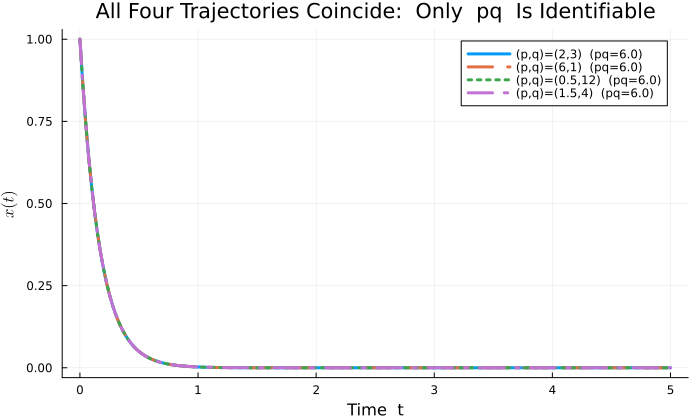

In [26]:
# ═══════════════════════════════════════════════════════════════
# Numerical verification: four (p,q) pairs sharing pq = 6
# collapse onto one output curve.
# ═══════════════════════════════════════════════════════════════

t = range(0, 5, length=200)
x0 = 1.0

pairs = [(2.0, 3.0), (6.0, 1.0), (0.5, 12.0), (1.5, 4.0)]
labels = ["(p,q)=(2,3)", "(p,q)=(6,1)", "(p,q)=(0.5,12)", "(p,q)=(1.5,4)"]
styles = [:solid, :dash, :dot, :dashdot]

pfig = plot(xlabel="Time  t", ylabel=L"x(t)",
    title="All Four Trajectories Coincide:  Only  pq  Is Identifiable",
    size=(700, 420), legend=:topright)

for (i, (p, q)) in enumerate(pairs)
    kappa = p * q
    y = x0 .* exp.(-kappa .* t)
    plot!(pfig, t, y, linewidth=3, linestyle=styles[i], label=labels[i] * "  (pq=$(kappa))")
end
pfig

### Identifiable combinations as a constructive object

Whenever `find_identifiable_functions` returns generators that are non-trivial functions of the original parameters, those generators are the model's *appropriate* parameter vector — for fitting, for reporting confidence intervals, and for comparing across independent studies (manuscript §6.2). Intervals on individually non-identifiable parameters reflect the prior or regulariser, not the data.

When reparameterisation alone does not yield a scientifically interpretable model, the manuscript (§6.3) lists three further remedies, all illustrated above:

| Remedy | Illustrated in |
|---|---|
| **Add measurements** | $T(t)$ in Case Study 4; $W(t)$ in Case Study 5; $y_2$ in Case Study 6 |
| **Fix parameters from external data** | e.g. fixing $d_T$ in the viral-dynamics model from an independent decay assay |
| **Add inputs** | the bolus input $u(t)$ in Case Study 3 |

In some cases a full second output trajectory is not even required — a single additional measurement at one time point can already restore identifiability or enlarge the identifiable field, a more economical option worth considering before committing to a full second observable.


---
## 13. Consolidated Verdicts <a id="sec-summary"></a>

*(Manuscript Table 3 and Figure 4.)* Verdicts as computed by the cells above (all initial conditions unknown).

| Model | Observed output | Verdict | Identifiable functions / parameter verdicts |
|---|---|---|---|
| Exponential decay | $y=x$ | **G** | $\{k\}$ |
| SIR | $y=\beta SI$ | **G** | $\{\beta,\gamma\}$ |
| Two-compartment PK | $y=x_2$, input $u$ | G/L | $\{a_{21},\,a_{01}{+}a_{12},\,a_{01}a_{12}\}$ |
| Two-compartment PK (central) | $y=x_1$, input $bu$ | **G** | $\{a_{01},a_{12},a_{21},b\}$ |
| Viral dynamics | $y=V$ | partial | $\{d_T,\beta,c{+}\delta,c\delta,ps\}$ |
| Viral dynamics, augmented | $y=(V,T)$ | G/L | $s,d_T,\beta,p$: G; $c,\delta$: L |
| SIWR (incidence) | incidence | partial | $\{\beta_I,\gamma{+}\mu,\gamma\mu,\beta_I\mu{+}\beta_W\xi\}$ |
| SIWR (incidence + $W$) | (incidence, $W$) | G/L | $\beta_I,\xi$: G; $\beta_W,\gamma,\mu$: L |
| SIWR (prevalence) | $y=I$ | partial | $\{\beta_I,\gamma,\mu,\beta_W\xi\}$ |
| SEIR-H | $y=\eta I$ | L/NI | $\{\sigma{+}\gamma{+}\eta,\sigma(\gamma{+}\eta),\beta/\eta\}$ (from the IO equation) |
| SEIR-H, augmented | $(\eta I,\beta SI)$ | L/NI | $\beta,\sigma,\gamma,\eta$: L; $\rho$: NI |
| Bilinear toy | $y=x$ | **NI** | $\{pq\}$ |


┌ Warning: Keyword argument bar_position not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, 

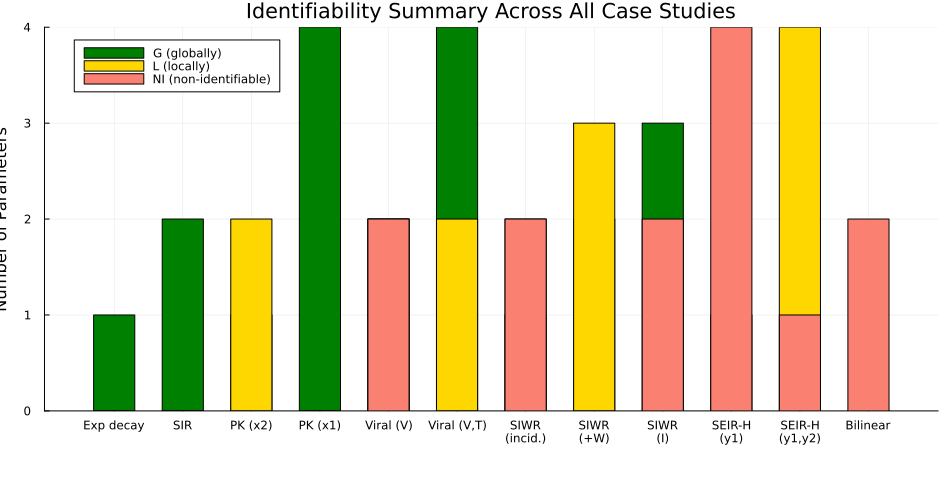

In [27]:
# ═══════════════════════════════════════════════════════════════
# Summary bar chart across case studies
# Fill in n_g / n_l / n_ni with your own run's results if they differ.
# ═══════════════════════════════════════════════════════════════

examples = ["Exp decay", "SIR", "PK (x2)", "PK (x1)", "Viral (V)", "Viral (V,T)",
            "SIWR\n(incid.)", "SIWR\n(+W)", "SIWR\n(I)", "SEIR-H\n(y1)", "SEIR-H\n(y1,y2)", "Bilinear"]

# G / L / NI parameter counts (excluding states), consistent with manuscript Table 3 and the consolidated table above
n_g  = [1, 2, 1, 4, 2, 4,  1, 2, 3, 0, 0, 0]
n_l  = [0, 0, 2, 0, 2, 2,  2, 3, 0, 1, 4, 0]
n_ni = [0, 0, 0, 0, 2, 0,  2, 0, 2, 4, 1, 2]

data = hcat(n_g, n_l, n_ni)

bar(data,
    bar_position = :stack,
    bar_width = 0.6,
    xticks = (1:length(examples), examples),
    ylabel = "Number of Parameters",
    title = "Identifiability Summary Across All Case Studies",
    label = ["G (globally)" "L (locally)" "NI (non-identifiable)"],
    color = [:green :gold :salmon],
    legend = :topleft,
    size = (950, 480),
    bottom_margin = 10Plots.mm)

---
## 14. The Structural-to-Practical Bridge: Fisher Information <a id="sec-practical"></a>

*(Manuscript §7.6.)* Structural identifiability is a necessary, but not sufficient, condition for reliable estimation. A structurally identifiable parameter can still be *practically* non-identifiable when the output's sensitivity to it is small relative to measurement noise (Raue et al., 2009). The Fisher information matrix (FIM) connects the algebraic question to the statistical one:

$$\mathcal{F}(\theta) = \sum_{k=1}^N \frac{1}{\sigma_k^2}\,\nabla_\theta y(t_k)\,\nabla_\theta y(t_k)^\top$$

Every structural non-identifiability manifests as a genuine zero eigenvalue of $\mathcal{F}$ (not merely a small one) — this is the kernel-containment bridge $\ker D\Phi \subseteq \ker\mathcal{F}$. We verify this below for the bilinear toy model of §12, whose non-identifiable direction we already know analytically.


In [28]:
# ═══════════════════════════════════════════════════════════════
# FIM demonstration: the structural kernel appears as a zero
# eigenvalue of the Fisher information matrix (bilinear toy model).
# y(t) = x0 * exp(-p*q*t)
# ═══════════════════════════════════════════════════════════════

p_true, q_true, x0_true = 2.0, 3.0, 1.0
t_meas = collect(range(0.1, 5.0, length=20))
sigma = 0.05

# Sensitivities dy/dp, dy/dq  (note both are proportional to (q, p) at every t)
dy_dp = [-q_true * ti * x0_true * exp(-p_true*q_true*ti) for ti in t_meas]
dy_dq = [-p_true * ti * x0_true * exp(-p_true*q_true*ti) for ti in t_meas]

Smat = hcat(dy_dp, dy_dq)
F = (1/sigma^2) * Smat' * Smat

println("Fisher information matrix (parameters: p, q):")
display(round.(F, digits=4))

evals, evecs = eigen(F)
println("\nEigenvalues of F:")
for (i, lam) in enumerate(evals)
    tag = lam < 1e-6 * maximum(evals) ? "  <-- (near-)zero: structural NI direction" : ""
    println("  lambda_$(i) = ", round(lam, sigdigits=4), tag)
end

# Theoretical kernel direction: orthogonal to (q, p) is (p, -q)
v_theory = [p_true, -q_true] / norm([p_true, -q_true])
println("\nTheoretical kernel direction (p, -q), normalized: ", round.(v_theory, digits=4))
println("Numerical eigenvector for the smallest eigenvalue:  ", round.(evecs[:,1], digits=4))
println("\nAlignment |<v_min, v_theory>| = ", round(abs(dot(evecs[:,1], v_theory)), digits=6))
println("=> The zero eigenvector of F aligns with the analytically predicted")
println("   non-identifiable direction, confirming ker(D-Phi) subset ker(F).")

2×2 Matrix{Float64}:
 18.0591  12.0394
 12.0394   8.0263

Fisher information matrix (parameters: p, q):

Eigenvalues of F:
  lambda_1 = -8.882e-16  <-- (near-)zero: structural NI direction
  lambda_2 = 26.09

Theoretical kernel direction (p, -q), normalized: [0.5547, -0.8321]
Numerical eigenvector for the smallest eigenvalue:  [0.5547, -0.8321]

Alignment |<v_min, v_theory>| = 1.0
=> The zero eigenvector of F aligns with the analytically predicted
   non-identifiable direction, confirming ker(D-Phi) subset ker(F).


---
## 15. Best Practices <a id="sec-best"></a>

*(Condensed from manuscript §7.)*

1. **Test identifiability before parameter estimation.** `assess_local_identifiability` is essentially free; run it as routinely as you would check solver tolerances.
2. **Start local, then go global.** If the local test certifies identifiability, the global test refines it to global-vs-local-only; if the local test fails, no global tool will help — the analysis terminates there.
3. **Treat the measurement scheme as part of the model.** The same dynamics can be identifiable for one output and not another (Case Studies 4–6 above).
4. **Be precise about initial conditions.** Whether $x_0$ is known, parameterised, or generic can overturn the verdict for half the parameters in a typical model.
5. **Use identifiable combinations as the reporting unit.** If `find_identifiable_functions` returns combinations, fit and report *those*, not the raw parameters.
6. **Distinguish structural from practical identifiability.** Structural identifiability is necessary but not sufficient; follow up with profile likelihood, the FIM (§14 above), or MCMC diagnostics.
7. **Know the practical limits.** The local test scales to large models; the global test and `find_identifiable_functions` can become expensive as the number of latent states, the differential order, and the polynomial degree grow — no universal size cutoff exists; benchmark your own model and consider sub-model analysis for larger systems-biology networks (`find_submodels`).
8. **Repeat the analysis after every model change.** Identifiability is not preserved under arbitrary reformulation.


---
## 16. Next Steps in the Julia SciML Ecosystem <a id="sec-next"></a>

*(Manuscript §4.)* Structural identifiability analysis is typically one stage in a larger modelling pipeline. The table below collects the packages a reader is likely to need next.

| Stage | Package(s) | Role |
|---|---|---|
| Model construction | `ModelingToolkit.jl`, `Catalyst.jl` | Acausal and reaction-network model specification (§4 above) |
| Importing standard formats | `SBMLImporter.jl`, `ReactionNetworkImporters.jl` | Import SBML / other exchange-format models as Catalyst `ReactionSystem`s |
| Parameter estimation | `Optimization.jl`, `PEtab.jl` | Numerical optimisers; `PEtab.jl` supports the community PEtab standard and multiple simulation conditions |
| Sensitivity analysis | `GlobalSensitivity.jl` | Global sensitivity indices, complementing the *structural* notion of identifiability used here |
| Bayesian inference | `Turing.jl` | Probabilistic programming and MCMC directly on `DifferentialEquations.jl` models |
| Practical identifiability | `LikelihoodProfiler.jl` | Profile-likelihood confidence intervals and practical (data-driven) identifiability, once structural identifiability is confirmed |

A typical workflow: build the model with `Catalyst.jl` or `ModelingToolkit.jl` → check structural identifiability with `StructuralIdentifiability.jl` (this notebook) → reparameterise using `find_identifiable_functions` if needed → fit with `PEtab.jl`/`Optimization.jl` or `Turing.jl` → assess practical identifiability with `LikelihoodProfiler.jl`.


---

> **Every parameter estimation study should include a structural identifiability analysis.** It identifies intrinsic limitations before data collection, guides model formulation and experimental design, and ensures the inverse problem is well posed — regardless of how much data you eventually collect.


---
## 17. References <a id="sec-references"></a>

### Foundational
1. Bellman, R. and Åström, K. J. (1970). "On structural identifiability." *Mathematical Biosciences*, 7(3–4), 329–339.
2. Pohjanpalo, H. (1978). "System identifiability based on the power series expansion of the solution." *Mathematical Biosciences*, 41(1–2), 21–33.
3. Cobelli, C. and DiStefano III, J. J. (1980). "Parameter and structural identifiability concepts and ambiguities: A critical review and analysis." *American Journal of Physiology*, 239(1), R7–R24.
4. Ljung, L. and Glad, T. (1994). "On global identifiability for arbitrary model parametrizations." *Automatica*, 30(2), 265–276.
5. Walter, E. and Pronzato, L. (1997). *Identification of Parametric Models from Experimental Data*. Springer.

### Methods and Software
6. Sedoglavic, A. (2002). "A probabilistic algorithm to test local algebraic observability in polynomial time." *Journal of Symbolic Computation*, 33(5), 735–755.
7. Villaverde, A. F., Barreiro, A., and Papachristodoulou, A. (2016). "Structural identifiability of dynamic systems biology models." *PLoS Computational Biology*, 12(10), e1005153.
8. Hong, H., Ovchinnikov, A., Pogudin, G., and Yap, C. (2019). "SIAN: Software for structural identifiability analysis of ODE models." *Bioinformatics*, 35(16), 2873–2874.
9. Hong, H., Ovchinnikov, A., Pogudin, G., and Yap, C. (2020). "Global identifiability of differential models." *Communications on Pure and Applied Mathematics*, 73(9), 1831–1879.
10. Ovchinnikov, A., Pogudin, G., and Thompson, P. (2021). "Parameter identifiability and input–output equations." *Applicable Algebra in Engineering, Communication and Computing*, 34(2), 165–182.
11. Ovchinnikov, A., Pillay, A., Pogudin, G., and Scanlon, T. (2022). "Computing all identifiable functions of parameters for ODE models." *Systems & Control Letters*, 157, 105030.
12. Dong, R., Goodbrake, C., Harrington, H. A., and Pogudin, G. (2023). "Differential elimination for dynamical models via projections with applications to structural identifiability." *SIAM Journal on Applied Algebra and Geometry*, 7(1), 194–235.
13. Ma, Y., Gowda, S., Anantharaman, R., Laughman, C., Shah, V., and Rackauckas, C. (2021). "ModelingToolkit: A composable graph transformation system for equation-based modeling." *arXiv:2103.05244*.
14. Loman, T. E., Ma, Y., Ilin, V., Gowda, S., Korsbo, N., Yewale, N., Rackauckas, C., and Isaacson, S. A. (2023). "Catalyst: Fast and flexible modeling of reaction networks." *PLoS Computational Biology*, 19(10), e1011530.
15. Rackauckas, C. and Nie, Q. (2017). "DifferentialEquations.jl: A performant and feature-rich ecosystem for solving differential equations in Julia." *Journal of Open Research Software*, 5(1), 15.
16. Bezanson, J., Edelman, A., Karpinski, S., and Shah, V. B. (2017). "Julia: A fresh approach to numerical computing." *SIAM Review*, 59(1), 65–98.

### Applications
17. Kermack, W. O. and McKendrick, A. G. (1927). "A contribution to the mathematical theory of epidemics." *Proceedings of the Royal Society A*, 115(772), 700–721.
18. Perelson, A. S., Neumann, A. U., Markowitz, M., Leonard, J. M., and Ho, D. D. (1996). "HIV-1 dynamics in vivo: Virion clearance rate, infected cell life-span, and viral generation time." *Science*, 271(5255), 1582–1586.
19. Miao, H., Xia, X., Perelson, A. S., and Wu, H. (2011). "On identifiability of nonlinear ODE models and applications in viral dynamics." *SIAM Review*, 53(1), 3–39.
20. Eisenberg, M. C., Robertson, S. L., and Tien, J. H. (2013). "Identifiability and estimation of multiple transmission pathways in cholera and waterborne disease." *Journal of Theoretical Biology*, 324, 84–102.
21. Raue, A., Kreutz, C., Maiwald, T., Bachmann, J., Schilling, M., Klingmüller, U., and Timmer, J. (2009). "Structural and practical identifiability analysis of partially observed dynamical models by exploiting the profile likelihood." *Bioinformatics*, 25(15), 1923–1929.
22. Liyanage, Y. R., Saucedo, O., Tuncer, N., and Chowell, G. (2025). "A tutorial on structural identifiability of epidemic models using StructuralIdentifiability.jl." *arXiv:2505.10517*.

### Companion Manuscript
23. Alsammani, A. (2026). "A Tutorial on Symbolic Structural Identifiability Analysis of ODE Models in Julia." Submitted to *Bulletin of Mathematical Biology*. Companion code archived on Zenodo, DOI: [10.5281/zenodo.18684344](https://doi.org/10.5281/zenodo.18684344).
